In [1]:
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
from matplotlib.cm import viridis
import seaborn as sns
%matplotlib inline

from ete3 import Tree
from ete3 import TreeStyle, NodeStyle, faces, AttrFace, CircleFace, TextFace

from Bio import SeqIO

import biotite.structure.io as bsio

#for Ete3
os.environ['QT_QPA_PLATFORM'] = 'offscreen'


In [2]:
## Get the paths setup
if '__file__' in globals():
    current_dir = Path(__file__).resolve().parent
else:
    current_dir = Path.cwd()

predicted_structures_dir = current_dir.parent / 'input_data' / 'predicted_structures'
sequences_dir = current_dir.parent / 'input_data' / 'sequence_info'
figures_dir = current_dir / 'figures'

print(os.path.exists(predicted_structures_dir))

True


In [3]:
bca_root = 'SDGIPKSEASERIKTGFLHFKKEKYDKNPALYGELAKGQSPPFMVFACSDSRVCPSHVLDFQPGEAFVVRNVANLVPPYDQAKYAGTGAAIEYAVLHLKVSNIVVIGHSACGGIKGLLSFPFDGTYSTDFIEEWVKIGLPAKAKVKAQHGDAPFAELCTHCEKEAVNASLGNLLTYPFVREGLVNKTLALKGGYYDFVKGSFELWGLEFGLSSTFSV'

In [4]:
blast_6_columns = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']

blast_peint_file = sequences_dir / 'peint'/ 'all_peint_seqs.csv'
blast_lg_file = sequences_dir / 'lg' / 'lg_blast.csv'

df = pd.read_csv(blast_peint_file, sep='\t', header=None, names=blast_6_columns)
df_lg = pd.read_csv(blast_lg_file, sep='\t', header=None, names=blast_6_columns)

In [5]:
bca_dict = dict()
for seq in df['qseqid'].unique():
    seqname, gene = seq.split('_')
    subdf = df.loc[df['qseqid'] == seq]
    #get max pident
    subdf = subdf.sort_values('pident', ascending=False)
    #get max pident
    max_pident = float(subdf['pident'].values[0])
    aln_length = float(subdf['length'].values[0])

    if gene == '1ekj':
        ratio = aln_length / len(bca_root)
        bca_dict[seqname] = (max_pident, ratio)

bca_lg_dict = dict()
for seq in df_lg['qseqid'].unique():
    if seq.startswith('internal'):
        continue
    subdf = df_lg.loc[df_lg['qseqid'] == seq]
    #get max pident
    subdf = subdf.sort_values('pident', ascending=False)
    #get max pident
    max_pident = float(subdf['pident'].values[0])
    aln_length = float(subdf['length'].values[0])

    ratio = aln_length / len(bca_root)

    bca_lg_dict[seq] = (max_pident, ratio)

In [6]:
bca_peint_plddts = dict()

bca_lg_plddts = dict()

bca_structure_dir = os.path.join(predicted_structures_dir, 'peint_14k_simulation_seed_42', '1ekj_1_C')
for f in os.listdir(bca_structure_dir):
    fname = os.path.join(bca_structure_dir, f)
    nodename = f.split('.')[0]
    if nodename == '': continue
    struct = bsio.load_structure(fname, extra_fields=["b_factor"])
    bca_peint_plddts[nodename] = float(struct.b_factor.mean())

bca_structure_dir_lg = os.path.join(predicted_structures_dir, 'lg', '1ekj_1_C')
for f in os.listdir(bca_structure_dir_lg):
    fname = os.path.join(bca_structure_dir_lg, f)
    nodename = f.split('.')[0]
    if nodename == '': continue
    struct = bsio.load_structure(fname, extra_fields=["b_factor"])
    bca_lg_plddts[nodename] = float(struct.b_factor.mean())

In [7]:
functional_file = sequences_dir / 'functional.txt' #growth curves based on in-vivo analysis

with open(functional_file, 'r') as fin:
    functional_nodes = fin.read().splitlines()

functional_dict = {n: n in functional_nodes for n in bca_peint_plddts.keys()}
print(dict(list(functional_dict.items())[:2]))

{'seq1251': True, 'seq1287': False}


In [8]:
data_dict = {
    k: {'peint_plddt': bca_peint_plddts[k],
        'lg_plddt': bca_lg_plddts[k],
        'functional': functional_dict[k]} for k in bca_peint_plddts.keys()
}

In [9]:
tree_file = sequences_dir / '1ekj_1_C.newick'
tree = Tree(str(tree_file), format=3)

In [10]:
tree_dist_dict = dict()
for k in bca_dict.keys():
    if not tree.search_nodes(name=k):
        continue
    tree_dist = tree.get_distance(k)
    if tree_dist < 1:
        #These are leaves that are super close to the picked root, since we reroot on a chosen leaf. They were not in consideration
        continue
    tree_dist_dict[k] = tree_dist

In [11]:
lg_aln = sequences_dir / 'lg' / '1ekj_1_C_root_aligned.txt'
peint_aln = sequences_dir / 'peint' / '1ekj_1_C_root_aligned.txt'

seqs = {r.id: str(r.seq) for r in SeqIO.parse(peint_aln, 'fasta')}
seqs_lg = {r.id: str(r.seq) for r in SeqIO.parse(lg_aln, 'fasta')}

divergence_data_peint = dict()
divergence_data_lg = dict()

root_seq_peint = seqs['root']
root_seq_lg = seqs_lg['root']

for seq in seqs:
    if seq =='root' or seq.startswith('internal'):
        continue
    sequence = seqs[seq]
    divergence = sum(1 for a, b in zip(root_seq_peint, sequence) if a != b) / len(root_seq_peint)
    divergence_data_peint[seq] = divergence

for seq in seqs_lg:
    if seq =='root' or seq.startswith('internal'):
        continue
    sequence = seqs_lg[seq]
    divergence = sum(1 for a, b in zip(root_seq_lg, sequence) if a != b) / len(root_seq_lg)
    divergence_data_lg[seq] = divergence

In [12]:
all_data = []
all_data_lg = []
for k in bca_dict.keys():
    pid = bca_dict[k][0]
    ratio = bca_dict[k][1]
    plddt = bca_peint_plddts.get(k, np.nan)
    tree_dist = tree_dist_dict.get(k, np.nan)
    functional = data_dict[k]['functional']
    dist_to_root = divergence_data_peint.get(k, np.nan)
    all_data.append({
        'node': k,
        'pid': pid,
        'ratio': ratio,
        'plddt': plddt,
        'tree_dist': tree_dist,
        'fraction_mutated_sites': dist_to_root,
        'functional': functional
    })
for k in bca_lg_plddts.keys():
    pid, ratio = bca_lg_dict.get(k, (np.nan, np.nan))
    plddt = bca_lg_plddts.get(k, np.nan)
    tree_dist = tree_dist_dict.get(k, np.nan)
    dist_to_root = divergence_data_lg.get(k, np.nan)
    all_data_lg.append({
        'node': k,
        'pid': pid,
        'ratio': ratio,
        'plddt': plddt,
        'tree_dist': tree_dist,
        'fraction_mutated_sites': dist_to_root,
    })

In [13]:
bca_df = pd.DataFrame(all_data)
bca_df = bca_df.dropna(subset=['plddt', 'tree_dist'])
bca_df_lg = pd.DataFrame(all_data_lg)
bca_df_lg = bca_df_lg.dropna(subset=['plddt', 'tree_dist'])

print(f"After filtering there are {len(bca_df)} leaves in the peint data")
print(f"After filtering there are {len(bca_df_lg)} leaves in the lg data")


After filtering there are 44 leaves in the peint data
After filtering there are 44 leaves in the lg data


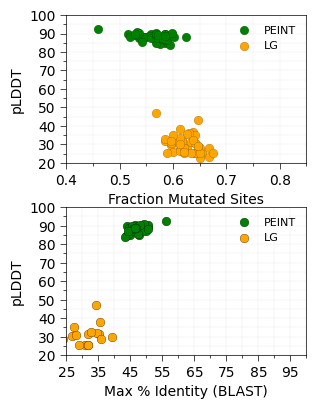

In [14]:
fig, axs = plt.subplots(2,1, figsize=(3, 4))
plt.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1, hspace=0.3)
axs[0].grid(True, which='both', linestyle='--', linewidth=0.1)

sns.scatterplot(data=bca_df, x='fraction_mutated_sites', y='plddt', ax=axs[0], s=40, linewidth=0.1, label='PEINT', color='green', edgecolor='black')
sns.scatterplot(data=bca_df_lg, x='fraction_mutated_sites', y='plddt', ax=axs[0], s=40, linewidth=0.1, label='LG', color='orange', edgecolor='black')


axs[0].set_xlim(0.4, 0.8)
axs[0].set_ylim(20, 100)
axs[0].set_xlabel('Fraction Mutated Sites')
axs[0].set_ylabel('pLDDT')
axs[0].set_xticks(np.arange(0.4, 0.9, 0.1), minor=False)
axs[0].set_xticks(np.arange(0.4, 0.9, 0.05), minor=True)
axs[0].tick_params(axis='both', which='major', width=0.5, length =4)
axs[0].tick_params(axis='both', which='minor', width=0.5, length =2)
axs[0].set_yticks(np.arange(20, 101, 10), minor=False)
axs[0].set_yticks(np.arange(20, 101, 5), minor=True)
axs[0].legend(loc='upper right', fontsize=8, frameon=False)


axs[1].grid(True, which='both', linestyle='--', linewidth=0.1)
sns.scatterplot(data=bca_df, x='pid', y='plddt', ax=axs[1], s=40, linewidth=0.2, label='PEINT', color='green', edgecolor='black')
sns.scatterplot(data=bca_df_lg, x='pid', y='plddt', ax=axs[1], s=40, linewidth=0.2, label='LG', color='orange', edgecolor='black')
axs[1].set_xlim(30, 100)
axs[1].set_ylim(25, 100)
axs[1].set_xlabel('Max % Identity (BLAST)')
axs[1].set_ylabel('pLDDT')
axs[1].set_xticks(np.arange(25, 101, 10), minor=False)
axs[1].set_xticks(np.arange(25, 101, 5), minor=True)
axs[1].tick_params(axis='both', which='major', width=0.5, length =4)
axs[1].tick_params(axis='both', which='minor', width=0.5, length =2)

axs[1].set_yticks(np.arange(20, 101, 10), minor=False)
axs[1].set_yticks(np.arange(20, 101, 5), minor=True)
axs[1].legend(loc='upper right', fontsize=8, frameon=False)

for ax in axs:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(axis='both', which='major', width=0.5, length=4)
    ax.tick_params(axis='both', which='minor', width=0.5, length=2)
    ax.set_axisbelow(True)

plt.savefig(os.path.join(figures_dir, 'bca_plddt_vs_tree_dist_and_pid.pdf'), bbox_inches='tight')

In [15]:
#prune the tree to the ordered leaves for display
ordered_file = sequences_dir / '1ekj_1_C_selected_sequences.fasta'
leaves_to_keep = [r.id.split('_')[0] for r in SeqIO.parse(ordered_file, 'fasta')]
print(leaves_to_keep)
tree.prune(leaves_to_keep)

['seq1738', 'seq1904', 'seq1729', 'seq1789', 'seq1670', 'seq1731', 'seq1944', 'seq1802', 'seq2148', 'seq1834', 'seq376', 'seq1251', 'seq771', 'seq1287', 'seq1436', 'seq1363', 'seq1496', 'seq1513', 'seq1420', 'seq1360']


In [16]:
def get_plDDT_color(plddt):
    """
    Convert pLDDT score to AlphaFold2 color scheme.
    Returns hex color string (#RRGGBB format)
    pLDDT range: <=50 -> 90
    Values below 50 are clamped to 50 (red)
    """
    # Clamp pLDDT to minimum of 50 before normalizing
    plddt_clamped = max(0.5, plddt)
    
    # Normalize pLDDT to 0-1 range (50-90 -> 0-1)
    norm_plddt = np.clip((plddt_clamped - 50) / 40, 0, 1)

    # Define color stops (pLDDT value -> RGB)
    colors = {
        0.0: (0.922, 0.000, 0.000),   # Red (pLDDT <= 50)  (#EB0000)
        0.25: (1.000, 0.490, 0.000),  # Orange (pLDDT = 60) (#FF7D00)
        0.5: (1.000, 1.000, 0.000),   # Yellow (pLDDT = 70) (#FFFF00)
        0.75: (0.490, 1.000, 0.000),  # Light green (pLDDT = 80) (#7DFF00)
        1.0: (0.000, 0.325, 0.839)    # Blue (pLDDT = 90) (#0053D6)
    }
    
    # Find the two closest color stops
    stops = sorted(colors.keys())
    for i, stop in enumerate(stops[1:]):
        if norm_plddt <= stop:
            t = (norm_plddt - stops[i]) / (stop - stops[i])
            color1 = colors[stops[i]]
            color2 = colors[stop]
            # Interpolate between colors
            interpolated_rgb = tuple(c1 * (1-t) + c2 * t for c1, c2 in zip(color1, color2))
            return "#{:02x}{:02x}{:02x}".format(
                int(interpolated_rgb[0] * 255),
                int(interpolated_rgb[1] * 255),
                int(interpolated_rgb[2] * 255)
            )
    
    return "#{:02x}{:02x}{:02x}".format(
        int(colors[1.0][0] * 255),
        int(colors[1.0][1] * 255),
        int(colors[1.0][2] * 255)
    )

# Function for functional status color
def get_functional_color(value):
    return "#00AA00" if value == 1 else "#808080"  # Green for functional, red for non-functional

CIRCLE_RADIUS = 5

def layout(node):
    if node.is_leaf():
        # Get data for this leaf
        node_name = node.name
        if node_name in data_dict:
            data = data_dict[node_name]
            
            # Add empty spacer
            faces.add_face_to_node(TextFace("  "), node, column=0, position="aligned")
            
            # Add neural net plDDT circle
            neural_plDDT = data['peint_plddt']
            neural_color = get_plDDT_color(neural_plDDT)
            neural_face = CircleFace(radius=CIRCLE_RADIUS, color=neural_color, style="circle")
            #neural_face.border.width = 1
            neural_face.opacity = 0.8
            # Add padding to improve alignment
            neural_face.margin_top = 2
            neural_face.margin_bottom = 2
            neural_face.margin_left = 5
            neural_face.margin_right = 5
            faces.add_face_to_node(neural_face, node, column=1, position="aligned")
            
            # Add LG plDDT circle
            lg_plDDT = data['lg_plddt']
            lg_color = get_plDDT_color(lg_plDDT)
            lg_face = CircleFace(radius=CIRCLE_RADIUS, color=lg_color, style="circle")
            #lg_face.border.width = 1
            lg_face.opacity = 0.8
            # Add padding to improve alignment
            lg_face.margin_top = 2
            lg_face.margin_bottom = 2
            lg_face.margin_left = 5
            lg_face.margin_right = 5
            faces.add_face_to_node(lg_face, node, column=2, position="aligned")
            
            # Add functional status circle
            functional = data['functional']
            func_color = get_functional_color(functional)
            if functional:
                func_face = CircleFace(radius=CIRCLE_RADIUS, color=func_color, style="circle")
            else:
                func_face = CircleFace(radius=0, color=func_color, style="circle")
            #func_face.border.width = 1
            func_face.opacity = 0.8
            # Add padding to improve alignment
            func_face.margin_top = 2
            func_face.margin_bottom = 2
            func_face.margin_left = 5
            func_face.margin_right = 5
            faces.add_face_to_node(func_face, node, column=3, position="aligned")

# Define the tree style
ts = TreeStyle()
ts.layout_fn = layout
ts.show_leaf_name = False  # We'll add names ourselves
ts.orientation = 0  # 0 = left to right (tree rooted on left, leaves on right), 1 = right to left, 2 = bottom to top, 3 = top to bottom
ts.scale = 100  # Scale branch length to make the tree more prominent
ts.branch_vertical_margin = 10  # Separation between branches
ts.show_scale = False  # Hide scale


# Adjust general node style
for n in tree.traverse():
    nstyle = NodeStyle()
    if n.is_leaf():
        nstyle["size"] = 6  # Node circle size for leaves
        nstyle["shape"] = "circle"
        nstyle["fgcolor"] = "#000000"  # Border color
        nstyle["hz_line_width"] = 1  # Horizontal line width
        nstyle["vt_line_width"] = 1  # Vertical line width
    else:
        nstyle["size"] = 0  # No visible circle for internal nodes
        nstyle["hz_line_width"] = 1  # Horizontal line width
        nstyle["vt_line_width"] = 1  # Vertical line width
    n.set_style(nstyle)


tree.render(os.path.join(figures_dir, "tree_summary.pdf"), tree_style=ts, w=200)

{'nodes': [[83.11999714350014,
   10.864971760703737,
   90.0340700821298,
   17.779044699333387,
   4,
   None],
  [71.41753360498724,
   37.53353880970382,
   78.3316065436169,
   44.44761174833347,
   6,
   None],
  [66.33420840803618,
   64.2021058587039,
   73.24828134666582,
   71.11617879733355,
   7,
   None],
  [63.901343685873506,
   90.87067290770398,
   70.81541662450316,
   97.78474584633364,
   11,
   None],
  [58.21173331018105,
   117.53923995670407,
   65.12580624881072,
   124.45331289533371,
   13,
   None],
  [67.32151826917838,
   144.20780700570415,
   74.23559120780804,
   151.12187994433378,
   14,
   None],
  [62.53460925635342,
   170.87637405470423,
   69.44868219498308,
   177.7904469933339,
   16,
   None],
  [57.1656340745664,
   197.5449411037043,
   64.07970701319604,
   204.45901404233396,
   17,
   None],
  [75.11942702880012,
   224.21350815270438,
   82.03349996742976,
   231.12758109133404,
   18,
   None],
  [57.17069122505865,
   250.8820752017044